In [4]:
# Retail Sales Analysis

''' 
Objective:
This project analyzes retail transaction data to identify sales trends,
customer purchasing behavior, high-value customers, and product performance. 
'''

'''
Tools Used:
- Python (Pandas)
- SQL
- Excel
- Power BI 
'''

''' 
Dataset:
Retail Sales Dataset containing transaction-level sales information. 
'''

' \nDataset:\nRetail Sales Dataset containing transaction-level sales information. \n'

In [5]:
#TASK 1 IMPORT DATA

In [6]:
import pandas as pd

data = pd.read_csv(r"D:\Data Analysis\DA projects\Data Sets\retail_sales_dataset.csv")
data.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-11-25,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-11-26,CUST003,Male,50,Electronics,1,30,30
3,4,2023-11-27,CUST004,Male,37,Clothing,1,500,500
4,5,2023-11-28,CUST005,Male,30,Beauty,2,50,100


In [7]:
# Data Understanding

"""
In this section we inspect:
- Number of rows and columns
- Data types
- Missing values
- Duplicate records
- Basic data quality checks
"""

'\nIn this section we inspect:\n- Number of rows and columns\n- Data types\n- Missing values\n- Duplicate records\n- Basic data quality checks\n'

In [8]:
#TASK 2: INSPECT DATA

In [56]:
#1 Rows
rows = data[0 : ]
rows


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-11-25,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-11-26,CUST003,Male,50,Electronics,1,30,30
3,4,2023-11-27,CUST004,Male,37,Clothing,1,500,500
4,5,2023-11-28,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2026-08-15,CUST996,Male,62,Clothing,1,50,50
996,997,2026-08-16,CUST997,Male,52,Beauty,3,30,90
997,998,2026-08-17,CUST998,Female,23,Beauty,4,25,100
998,999,2026-08-18,CUST999,Female,36,Electronics,3,50,150


In [16]:
#2 Column Names

list(data.columns)

['Transaction ID',
 'Date',
 'Customer ID',
 'Gender',
 'Age',
 'Product Category',
 'Quantity',
 'Price per Unit',
 'Total Amount']

In [17]:
#3 Data Types
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


In [18]:
#4 Missing Values
data.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [19]:
#5 Duplicates
data.duplicated().sum()

np.int64(0)

In [20]:
# Data Preparation

"""
This section prepares the dataset for analysis by:
- Converting dates
- Creating Month and Quarter features
- Ensuring data consistency
"""

'\nThis section prepares the dataset for analysis by:\n- Converting dates\n- Creating Month and Quarter features\n- Ensuring data consistency\n'

In [21]:
# Task 3: Data Quality Report

In [22]:
#1 Are the data types correct ?
data['Date'].info()

<class 'pandas.Series'>
RangeIndex: 1000 entries, 0 to 999
Series name: Date
Non-Null Count  Dtype
--------------  -----
1000 non-null   str  
dtypes: str(1)
memory usage: 7.9 KB


In [23]:
#2 Doest the data make business sense ?
Total_Sales = data['Quantity'] * data['Price per Unit']
print("Total_Sales:")
print(Total_Sales.sum())

print("\n Total Revenue:")
print(data['Total Amount'].all())

Total_Sales:
456000

 Total Revenue:
True


In [24]:
#3 DATA QUALITY REPORT
#written in notes

In [57]:
#Phase 3:- Data Cleaning
#Task 1
#1 create a copy of the dataset.

clean_data = data.copy()
clean_data

#2 verify shape of both data
print("shape of original Data:")
print(data.shape)

print("\n shape of the copied data")
print(clean_data.shape)


#3 Convert Date into datetime
clean_data['Date'] = pd.to_datetime(data['Date'], dayfirst=True)


#4 Verify the Conversion
print(clean_data['Date'])

shape of original Data:
(1000, 9)

 shape of the copied data
(1000, 9)
0     2023-11-24
1     2023-11-25
2     2023-11-26
3     2023-11-27
4     2023-11-28
         ...    
995   2026-08-15
996   2026-08-16
997   2026-08-17
998   2026-08-18
999   2026-08-19
Name: Date, Length: 1000, dtype: datetime64[us]


C:\Users\karth\AppData\Local\Temp\ipykernel_12204\2409197843.py:17: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  clean_data['Date'] = pd.to_datetime(data['Date'], dayfirst=True)


In [26]:
clean_data['Date']

0     2023-11-24
1     2023-11-25
2     2023-11-26
3     2023-11-27
4     2023-11-28
         ...    
995   2026-08-15
996   2026-08-16
997   2026-08-17
998   2026-08-18
999   2026-08-19
Name: Date, Length: 1000, dtype: datetime64[us]

In [28]:
#Phase 4
# Exploratory Data Analysis

"""
This section answers the key business questions identified during the
Business Understanding phase.
"""

'\nThis section answers the key business questions identified during the\nBusiness Understanding phase.\n'

In [58]:
#Phase 4:- Exploratory Data Analysis (EDA)
#Task 1:- Business Questions
#1 Product Category with highest revenue ?

Total_revenue = clean_data["Total Amount"].sum()
Total_revenue
    
revenue_by_category = (
    clean_data
    .groupby('Product Category')['Total Amount']
    .sum()
    .sort_values(ascending=False)
)

Contribution = (revenue_by_category/Total_revenue) * 100
Contribution = Contribution.round(2)

print(revenue_by_category)
print(Contribution)

#Convert the results into table:
Table = pd.DataFrame({
    'Revenue' : revenue_by_category,
    'Contribution (%)' : Contribution
})
Table

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64
Product Category
Electronics    34.41
Clothing       34.12
Beauty         31.47
Name: Total Amount, dtype: float64


,Revenue,Contribution (%)
Product Category,,
Electronics,156905,34.41
Clothing,155580,34.12
Beauty,143515,31.47


In [31]:
# Convert column index into normal column.
Table = Table.reset_index()
Table.sort_values(by='Revenue', ascending=False)

,Product Category,Revenue,Contribution (%)
0,Electronics,156905,34.41
1,Clothing,155580,34.12
2,Beauty,143515,31.47


In [59]:
#2 Which gender purchasing more ?

Revenue = clean_data.groupby('Gender')['Total Amount'].sum()
Revenue

Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64

In [34]:
#3 Which Month Generated Highest Sales ?

#To Create Month column in dataset.
clean_data['Month_Name'] = clean_data['Date'].dt.month_name()
clean_data['Month'] = clean_data['Date'].dt.month

Monthly_Sales = ( 
    clean_data
    .groupby(['Month', 'Month_Name'])['Total Amount']
    .sum()
    .reset_index()
    .sort_values('Month')
)
Monthly_Sales

,Month,Month_Name,Total Amount
0,1,January,45735
1,2,February,41885
2,3,March,50610
3,4,April,42215
4,5,May,34020
5,6,June,41565
6,7,July,37725
7,8,August,36695
8,9,September,26995
9,10,October,27790


In [35]:
"""
**Observation:** Electronics generated the highest total revenue.

**Business Impact:** Electronics is a critical revenue-driving category.

**Recommendation:** Ensure sufficient inventory and continue investing in
marketing and cross-selling opportunities for Electronics products.
"""

'\n**Observation:** Electronics generated the highest total revenue.\n\n**Business Impact:** Electronics is a critical revenue-driving category.\n\n**Recommendation:** Ensure sufficient inventory and continue investing in\nmarketing and cross-selling opportunities for Electronics products.\n'

In [36]:
#Pivot table in pandas

pd.pivot_table(
    clean_data,
    index = 'Gender',
    columns = 'Product Category',
    values = 'Total Amount',
    aggfunc = 'sum'
)

Product Category,Beauty,Clothing,Electronics
Gender,,,
Female,74830,81275,76735
Male,68685,74305,80170


In [37]:
# To Calculate Average
pd.pivot_table(
    clean_data,
    index = 'Gender',
    columns = 'Product Category',
    values = 'Total Amount',
    aggfunc = 'mean'
)

Product Category,Beauty,Clothing,Electronics
Gender,,,
Female,450.783133,467.097701,451.382353
Male,487.127660,419.802260,466.104651


In [60]:
driver_analysis = (
    clean_data
    .groupby('Product Category')
    .agg(
        Total_Revenue=('Total Amount', 'sum'),
        Total_Quantity=('Quantity', 'sum'),
        Average_Price=('Price per Unit', 'mean')
    )
)

driver_analysis

,Total_Revenue,Total_Quantity,Average_Price
Product Category,,,
Beauty,143515,771,184.055375
Clothing,155580,894,174.287749
Electronics,156905,849,181.900585


In [39]:
#Total_Customers
Total_Customers = clean_data.groupby('Gender')['Gender'].count()
Total_Customers

Gender
Female    510
Male      490
Name: Gender, dtype: int64

In [40]:
#Revenue From Customers
Customer_Revenue = (
    clean_data.groupby('Customer ID')['Total Amount']
    .sum()
    .sort_values(ascending=False)
)
Customer_Revenue

Customer ID
CUST015    2000
CUST412    2000
CUST970    2000
CUST547    2000
CUST281    2000
           ... 
CUST379      25
CUST952      25
CUST371      25
CUST397      25
CUST955      25
Name: Total Amount, Length: 1000, dtype: int64

In [41]:
#Top Spending Customers
Top_Customers = Customer_Revenue.head(49)
Top_Customers

Customer ID
CUST015    2000
CUST412    2000
CUST970    2000
CUST547    2000
CUST281    2000
CUST416    2000
CUST420    2000
CUST927    2000
CUST447    2000
CUST342    2000
CUST561    2000
CUST065    2000
CUST487    2000
CUST572    2000
CUST503    2000
CUST480    2000
CUST476    2000
CUST152    2000
CUST743    2000
CUST773    2000
CUST139    2000
CUST093    2000
CUST089    2000
CUST634    2000
CUST664    2000
CUST626    2000
CUST253    2000
CUST875    2000
CUST072    2000
CUST074    2000
CUST595    2000
CUST269    2000
CUST257    2000
CUST592    2000
CUST577    2000
CUST946    2000
CUST742    2000
CUST155    2000
CUST157    2000
CUST789    2000
CUST808    2000
CUST124    2000
CUST118    2000
CUST166    2000
CUST109    2000
CUST735    2000
CUST731    2000
CUST832    2000
CUST700    2000
Name: Total Amount, dtype: int64

In [42]:
#Total Spendings of Top Customers
Total_Spending = Top_Customers.sum()
print(Total_Spending)

98000


In [43]:
#Overall Total Revenue
Total_Revenue = clean_data['Total Amount'].sum()
print(Total_Revenue)

456000


In [44]:
Top_Spending_Customers = (Total_Spending/Total_Revenue) * 100
Top_Spending_Customers = Top_Spending_Customers.round(2)
print(Top_Spending_Customers)

21.49


In [45]:
# Quantity of electronics vs pricing of electronics

#1 Revenue by Category
Product_Revenue = (
    clean_data
        .groupby('Product Category')['Total Amount']
        .sum()
        .sort_values(ascending=False)
)
print(Product_Revenue)

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64


In [46]:
#2 Total Quantity sold by Category
Product_Quantity = (
    clean_data
        .groupby('Product Category')['Quantity']
        .sum()
        .sort_values(ascending=False)
)
print(Product_Quantity)

Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64


In [47]:
#Average Price per Unit by Category
Average_price =( 
    clean_data
        .groupby('Product Category')['Price per Unit']
        .mean()
        .sort_values(ascending=False)
        .round(2)
)
print(Average_price)    

Product Category
Beauty         184.06
Electronics    181.90
Clothing       174.29
Name: Price per Unit, dtype: float64


In [66]:
#Quarterly Sales Analysis
#1 Add quarter column to dataset.

clean_data['Quarter'] = clean_data['Date'].dt.quarter

#2 Calculate Quarterly Sales
Quarterly_Sales = ( 
    clean_data
    .groupby('Quarter')['Total Amount']
    .sum()
    .reset_index()
)
print('Quartely_Sales:')
print(Quarterly_Sales)

#3 Quarterly Sales based on Product Category
Quarterly_Categories_Sales = (
    clean_data
    .groupby(['Quarter','Product Category'])['Total Amount']
    .sum()
)
print('\n Quarterly_Categories_Sales:')
print(Quarterly_Categories_Sales)

Quartely_Sales:
   Quarter  Total Amount
0        1        138230
1        2        117800
2        3        101415
3        4         98555

 Quarterly_Categories_Sales:
Quarter  Product Category
1        Beauty              41770
         Clothing            43285
         Electronics         53175
2        Beauty              39765
         Clothing            39375
         Electronics         38660
3        Beauty              37780
         Clothing            38325
         Electronics         25310
4        Beauty              24200
         Clothing            34595
         Electronics         39760
Name: Total Amount, dtype: int64


In [49]:
# Key Business Insights

"""
1. Electronics is the highest revenue-generating category.
2. Clothing has the highest sales volume.
3. Beauty products have the highest average price per unit.
4. Sales performance varies across months and quarters.
5. A relatively small group of customers contributes a meaningful share of revenue.
6. Customer purchasing preferences differ between genders.
"""

'\n1. Electronics is the highest revenue-generating category.\n2. Clothing has the highest sales volume.\n3. Beauty products have the highest average price per unit.\n4. Sales performance varies across months and quarters.\n5. A relatively small group of customers contributes a meaningful share of revenue.\n6. Customer purchasing preferences differ between genders.\n'

In [50]:
# Strategic Recommendations

"""
- Prioritize Electronics inventory and marketing investment.
- Use gender-based targeted promotions for Beauty, Clothing, and Electronics.
- Monitor quarterly performance to identify declining categories early.
- Develop retention programs for high-value customers.
- Investigate seasonal patterns to optimize future campaigns and inventory planning.
"""

'\n- Prioritize Electronics inventory and marketing investment.\n- Use gender-based targeted promotions for Beauty, Clothing, and Electronics.\n- Monitor quarterly performance to identify declining categories early.\n- Develop retention programs for high-value customers.\n- Investigate seasonal patterns to optimize future campaigns and inventory planning.\n'

In [53]:
# Save Cleanded Dataset

clean_data.to_csv(
    r"D:\Data Analysis\DA projects\Data Sets\new_retail_sales_cleaned.csv",
    index=False
)

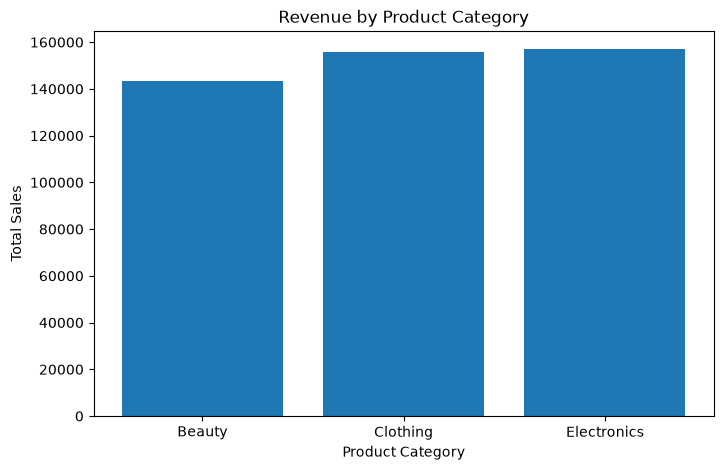

In [55]:
# Visualization Phase:
# Lesson 1: Matplotlib Basics

#Import matplotlib library 
import matplotlib.pyplot as plt

#This creates a blank canvas for your chart.
plt.figure(figsize=(8,5))
#Example: 8 = width, 5 = height

''' plt.bar(x_values, y_values) '''
#Compares Categories

#Example:
categories = ['Beauty', 'Clothing', 'Electronics']
sales = [143515, 155580, 156905]

plt.bar(categories, sales)
#This creates Three bars showing sales for each Category.

#plt.xlabel() & plt.ylabel()
#These add axis labels.

plt.xlabel('Product Category')
plt.ylabel('Total Sales')
# Without labels, Stakeholders may not understand the chart.

# plt.title() Adds Title to the Chart
plt.title('Revenue by Product Category')

#plt.show() Displays the chart.
plt.show()
#Always place it at the end of the chart code.

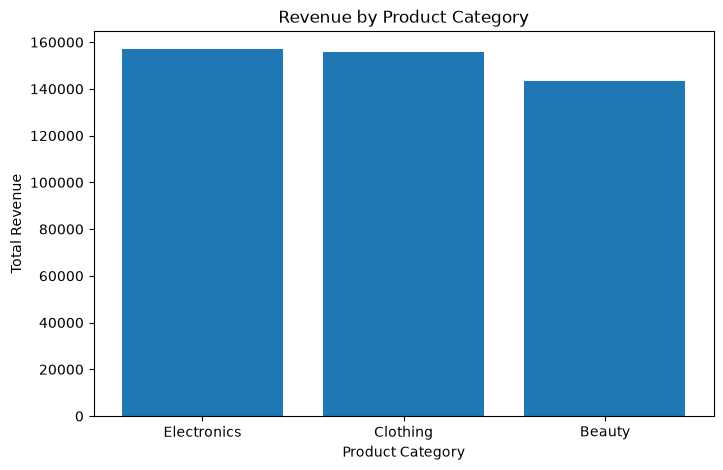

In [56]:
#first Chart 

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    revenue_by_category.index,
    revenue_by_category.values
)

plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.title('Revenue by Product Category')

plt.show()

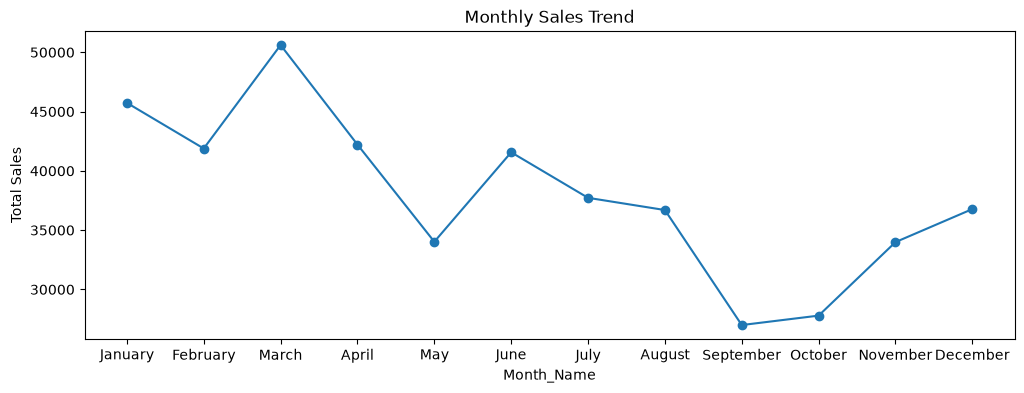

In [61]:
# Monthly Sales Trend Visualization

plt.figure(figsize=(12,4))

plt.plot(
    Monthly_Sales['Month_Name'],
    Monthly_Sales['Total Amount'],
    marker='o'
)

plt.xlabel('Month_Name')
plt.ylabel('Total Sales')
plt.title('Monthly Sales Trend')

plt.show()

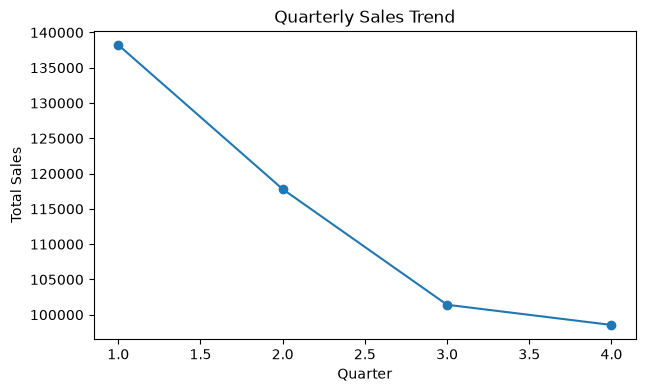

In [67]:
# Quarterly Sales Trend Visulization

plt.figure(figsize=(7,4))

plt.plot(
    Quarterly_Sales['Quarter'],
    Quarterly_Sales['Total Amount'],
    marker='o'
)

plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.title('Quarterly Sales Trend')

plt.show()

In [65]:
# To Convert dataset into SQL Format:

clean_data['Date'] = pd.to_datetime(
    clean_data['Date'],
    format='%Y-%m-%d'
)

clean_data.to_csv(
    r"D:\Data Analysis\DA projects\Data Sets\retail_sales_mysql.csv",
    index=False,
    date_format='%Y-%m-%d'
)

In [ ]:
# SQL Business Insights

## Executive Summary

- Total Sales: ₹456,000
- Total Customers: 1,000
- Total Transactions: 1,000
- Total Quantity Sold: 2,514
- Electronics is the highest revenue-generating category.
- Customer CUST103 is the highest-spending customer with ₹2,000 in revenue.

## Key Insight

The business shows strong revenue contribution from the Electronics category,
while customer spending varies significantly,
with certain customers contributing substantially more than the average customer.